# Week 08. Learning Principles of Artificial Neural Networks

---

## 학습 목표

이 노트북을 마치면 다음을 할 수 있습니다.

1. **activation function**의 역할을 설명할 수 있다.
2. 간단한 **DNN(MLP)** 모델을 직접 정의할 수 있다.
3. `loss.backward()`가 하는 일을 설명할 수 있다.
4. 각 층의 weight와 bias에 gradient가 어떻게 저장되는지 확인할 수 있다.
5. gradient를 이용해 파라미터를 직접 한 번 업데이트할 수 있다.
6. update 전후 loss 변화를 비교할 수 있다.
7. 실제 도시 데이터인 **Seoul Bike Sharing Demand** 자료에 neural network를 적용할 수 있다.

## 1. 왜 neural network가 필요한가?

Linear model은 입력을 한 번에 출력으로 바꿉니다.

$$
y = Wx + b
$$

그런데 현실의 데이터는 훨씬 더 복잡합니다. 그래서 우리는 중간에 **hidden layer**를 두고,
각 층마다 **activation function**을 넣어서 더 복잡한 표현을 만들 수 있게 합니다.

구조는 다음과 같습니다.

```
data → linear → activation → linear → output
```

**모델의 구조와 데이터 흐름**을 먼저 확인합니다.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('NumPy version  :', np.__version__)
print('Pandas version :', pd.__version__)
print('PyTorch version:', torch.__version__)

NumPy version  : 2.5.2
Pandas version : 3.0.5
PyTorch version: 2.13.0+cpu


 ## 2. Activation Function

Activation function은 입력값을 다음 층으로 넘기기 전에 일정한 규칙으로 변환하는 함수입니다.

- 입력값 하나를 넣으면
- 규칙에 따라 값을 조금 바꾸고
- 그 결과를 다음 층으로 넘긴다.

여기서는 Sigmoid function을 사용합니다.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Sigmoid의 출력값은 0과 1 사이입니다.

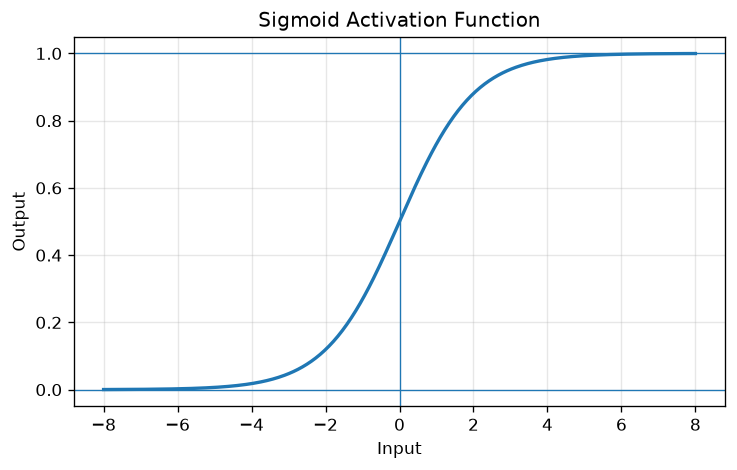

input   : [-5. -2.  0.  2.  5.]
sigmoid : [0.0067 0.1192 0.5    0.8808 0.9933]


In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-8, 8, 400)

plt.figure(figsize=(7, 4))
plt.plot(x, sigmoid(x), linewidth=2)
plt.axhline(0, linewidth=0.8)
plt.axhline(1, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title('Sigmoid Activation Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(alpha=0.3)
plt.show()

values = np.array([-5.0, -2.0, 0.0, 2.0, 5.0])

print('input   :', values)
print('sigmoid :', np.round(sigmoid(values), 4))

## 3. `nn.Linear`는 정확히 무엇을 할까?

PyTorch의 `nn.Linear(in_features, out_features)`는 다음 계산을 합니다.

$$
out = xW^T + b
$$

**shape**를 함께 확인해보겠습니다.

- 입력이 `(batch_size, in_features)`
- 출력이 `(batch_size, out_features)`

즉, 샘플 여러 개를 한 번에 처리합니다.


In [4]:
linear = nn.Linear(3, 4)
example_x = torch.tensor([
    [0.2, 0.7, 1.0],
    [1.2, -0.3, 0.5],
], dtype=torch.float32)
example_out = linear(example_x)

print('input shape :', tuple(example_x.shape))
print('weight shape:', tuple(linear.weight.shape))
print('bias shape  :', tuple(linear.bias.shape))
print('output shape:', tuple(example_out.shape))
print(example_out)

input shape : (2, 3)
weight shape: (4, 3)
bias shape  : (4,)
output shape: (2, 4)
tensor([[ 0.7150,  0.2122,  0.9685,  0.2931],
        [ 0.7448,  0.8108,  0.0938, -0.6863]], grad_fn=<AddmmBackward0>)


## 4. DNN 모델 만들기

가장 기본적인 **MLP(Multi-Layer Perceptron)** 를 만듭니다.

구조는 다음과 같습니다.

1. 입력층에 변수를 입력한다.
2. hidden layer 1개를 지난다.
3. activation을 적용한다.
4. 출력층에서 예측값을 1개 도출한다.

먼저 hidden layer 1개인 구조부터 보겠습니다.

In [5]:
model = nn.Sequential(
    nn.Linear(11, 16),
    nn.Sigmoid(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=11, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


## 5. SeoulBikeData 불러오기

이번 실습에서는 Seoul Bike Sharing Demand 데이터를 사용합니다.

### 사용할 입력 변수

- Temperature(C)
- Humidity(%)
- Wind speed (m/s)
- Visibility (10m)
- Solar Radiation (MJ/m2)
- Rainfall(mm)
- Snowfall (cm)
- Seasons

### 출력 변수

- Rented Bike Count


### 계절 자료는 어떻게 변환해야 할까?

`Seasons`는 `Spring`, `Summer`, `Autumn`, `Winter`와 같은 **문자형 범주**입니다.

하지만 neural network는 숫자를 입력으로 받기 때문에,
각 계절을 숫자형 열로 바꾸어야 합니다.

이를 **one-hot encoding**이라고 합니다.

예를 들어 `Winter`는 다음과 같이 표현할 수 있습니다.

```text
Season_Spring  Season_Summer  Season_Autumn  Season_Winter
      0              0              0              1
```

따라서 7개의 연속형 변수와 4개의 계절 변수를 합쳐
총 **11개의 input node**를 사용하게 됩니다.

또한 각 연속형 변수는 단위와 범위가 다르므로,
이번 실습에서는 평균이 0, 표준편차가 1에 가까워지도록 **standardization**을 적용합니다.

In [7]:
url = "https://raw.githubusercontent.com/jn0704/Lecture-Sample-Wonjun-No-dataset/main/data/SeoulBikeData.csv"
df = pd.read_csv(url)

selected_columns = [
    'Rented Bike Count',
    'Temperature(C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Seasons'
]

df = df[selected_columns].copy()

print('data shape:', df.shape)
df.head(10)

data shape: (8465, 9)


,Rented Bike Count,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons
0,254,-5.2,37,2.2,2000,0.00,0.0,0.0,Winter
1,204,-5.5,38,0.8,2000,0.00,0.0,0.0,Winter
2,173,-6.0,39,1.0,2000,0.00,0.0,0.0,Winter
3,107,-6.2,40,0.9,2000,0.00,0.0,0.0,Winter
4,78,-6.0,36,2.3,2000,0.00,0.0,0.0,Winter
5,100,-6.4,37,1.5,2000,0.00,0.0,0.0,Winter
6,181,-6.6,35,1.3,2000,0.00,0.0,0.0,Winter
7,460,-7.4,38,0.9,2000,0.00,0.0,0.0,Winter
8,930,-7.6,37,1.1,2000,0.01,0.0,0.0,Winter
9,490,-6.5,27,0.5,1928,0.23,0.0,0.0,Winter


In [8]:
# One-hot encoding for Seasons
season_categories = ['Spring', 'Summer', 'Autumn', 'Winter']
season = pd.Categorical(df['Seasons'], categories=season_categories)

season_dummy = pd.get_dummies(
    season,
    prefix='Season',
    dtype=float
)

df_encoded = pd.concat(
    [df.drop(columns='Seasons'), season_dummy],
    axis=1
)

print('encoded data shape:', df_encoded.shape)
df_encoded.head(10)

encoded data shape: (8465, 12)


,Rented Bike Count,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Season_Spring,Season_Summer,Season_Autumn,Season_Winter
0,254,-5.2,37,2.2,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
1,204,-5.5,38,0.8,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
2,173,-6.0,39,1.0,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
3,107,-6.2,40,0.9,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
4,78,-6.0,36,2.3,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
5,100,-6.4,37,1.5,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
6,181,-6.6,35,1.3,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
7,460,-7.4,38,0.9,2000,0.00,0.0,0.0,0.0,0.0,0.0,1.0
8,930,-7.6,37,1.1,2000,0.01,0.0,0.0,0.0,0.0,0.0,1.0
9,490,-6.5,27,0.5,1928,0.23,0.0,0.0,0.0,0.0,0.0,1.0


### 입력값 standardization

현재 입력 변수들의 범위는 서로 다릅니다.

예를 들어,

- Humidity는 대략 `0 ~ 100`
- Visibility는 최대 `2000`
- Solar Radiation은 훨씬 작은 범위

를 가집니다.

신경망에 서로 다른 크기의 값을 그대로 넣기보다,
이번 실습에서는 연속형 입력변수를 다음과 같이 표준화합니다(z-score normalization).

$$
x' = \frac{x-\mu}{\sigma}
$$

`Rented Bike Count`는 실제 대여량 단위 그대로 유지합니다.

In [9]:
numeric_features = [
    'Temperature(C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

df_processed = df_encoded.copy()

for col in numeric_features:
    mean = df_processed[col].mean()
    std = df_processed[col].std()
    df_processed[col] = (df_processed[col] - mean) / std

input_columns = [
    'Temperature(C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Season_Spring',
    'Season_Summer',
    'Season_Autumn',
    'Season_Winter'
]

X = torch.tensor(
    df_processed[input_columns].to_numpy(dtype=np.float32),
    dtype=torch.float32
)

y = torch.tensor(
    df_processed['Rented Bike Count'].to_numpy(dtype=np.float32),
    dtype=torch.float32
).view(-1, 1)

print('X shape:', tuple(X.shape))
print('y shape:', tuple(y.shape))
print('number of input nodes:', X.shape[1])

X shape: (8465, 11)
y shape: (8465, 1)
number of input nodes: 11


### 데이터 확인

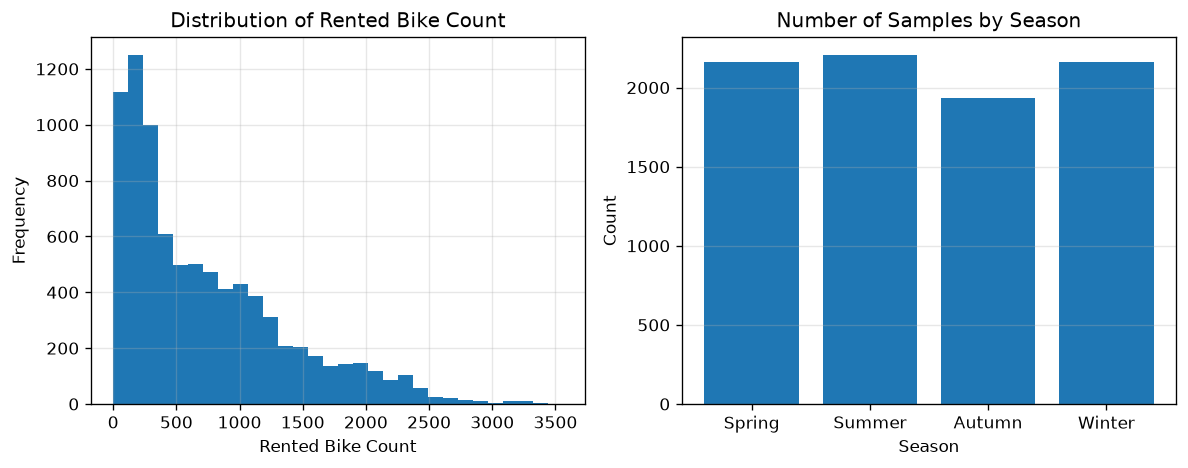

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df['Rented Bike Count'], bins=30)
axes[0].set_title('Distribution of Rented Bike Count')
axes[0].set_xlabel('Rented Bike Count')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

season_counts = df['Seasons'].value_counts().reindex(season_categories)
axes[1].bar(season_counts.index, season_counts.values)
axes[1].set_title('Number of Samples by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feed Forward 해보기

이제 이미지를 모델에 넣고 출력값을 확인합니다.

아직 학습하지 않은 모델이므로 weight와 bias는 임의의 초기값을 가지고 있습니다.

먼저, Seoul Bike 데이터의 **10개 행**을 모델에 넣고 출력값을 확인합니다.

In [11]:
X_small = X[:10]
y_small = y[:10]

with torch.no_grad():
    predictions = model(X_small)

print('input shape      :', tuple(X_small.shape))
print('prediction shape :', tuple(predictions.shape))
print()

result = pd.DataFrame({
    'Actual': y_small.squeeze().numpy(),
    'Prediction': predictions.squeeze().numpy()
})

result

input shape      : (10, 11)
prediction shape : (10, 1)



,Actual,Prediction
0,254.0,-0.251913
1,204.0,-0.246810
2,173.0,-0.247302
3,107.0,-0.247334
4,78.0,-0.250808
5,100.0,-0.247287
6,181.0,-0.245138
7,460.0,-0.244517
8,930.0,-0.244146
9,490.0,-0.238542


## 7. Hidden Dimension을 바꾸면?

모델의 hidden size는 대표적인 하이퍼파라미터입니다.

아래 셀은 hidden dimension만 바꿔서 출력 shape가 어떻게 유지되는지 확인하는 예제입니다.

In [12]:
for hidden_dim in [8, 16, 32, 64]:

    temp_model = nn.Sequential(
        nn.Linear(11, hidden_dim),
        nn.Sigmoid(),
        nn.Linear(hidden_dim, 1)
    )

    with torch.no_grad():
        temp_output = temp_model(X_small)

    n_params = sum(p.numel() for p in temp_model.parameters())

    print(
        f'hidden_dim={hidden_dim:2d} '
        f'-> output shape={tuple(temp_output.shape)}, '
        f'parameters={n_params}'
    )

hidden_dim= 8 -> output shape=(10, 1), parameters=105
hidden_dim=16 -> output shape=(10, 1), parameters=209
hidden_dim=32 -> output shape=(10, 1), parameters=417
hidden_dim=64 -> output shape=(10, 1), parameters=833


## 8. Backpropagation 개요

신경망 학습은 보통 다음 순서로 진행됩니다.

```text
forward -> loss 계산 -> backward -> update
```

- **forward**: 입력을 넣어 출력값을 계산
- **loss**: 예측과 실제값의 차이를 계산
- **backward**: 각 파라미터의 gradient 계산
- **update**: gradient를 사용해 파라미터 수정

실습에서는 이 흐름을 작은 예제로 확인합니다.

## 9. 작은 식에서 gradient 보기

다음 식을 생각해봅시다.

$$
y = wx + b, \quad L = (y-t)^2
$$

PyTorch는 이 계산 과정을 추적하고,
`backward()`를 호출하면 필요한 미분값을 자동으로 계산합니다.

In [13]:
x_small = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(-0.4, requires_grad=True)
b = torch.tensor(0.3, requires_grad=True)
t = torch.tensor(1.0)

y_pred = w * x_small + b
loss = (y_pred - t) ** 2

loss.backward()

print(f'y        = {y_pred.item():.4f}')
print(f'loss     = {loss.item():.4f}')
print(f'dL/dw    = {w.grad.item():.4f}')
print(f'dL/db    = {b.grad.item():.4f}')
print(f'dL/dx    = {x_small.grad.item():.4f}')

y        = -0.5000
loss     = 2.2500
dL/dw    = -6.0000
dL/db    = -3.0000
dL/dx    = 1.2000


## 10. Forward와 Loss 계산

이번에는 Seoul Bike 데이터를 이용해 다시 **11-16-1 DNN**을 만듭니다.

```text
Linear(11, 16) -> Sigmoid -> Linear(16, 1)
```

출력값 `Rented Bike Count`는 연속형 숫자이므로, **Mean Squared Error (MSE)** 를 사용합니다.

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
$$

먼저 하나의 batch를 모델에 넣고 loss를 계산해보겠습니다.

In [14]:
dataset = TensorDataset(X, y)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

X_batch, y_batch = next(iter(train_loader))

model = nn.Sequential(
    nn.Linear(11, 16),
    nn.Sigmoid(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()

predictions = model(X_batch)
loss = criterion(predictions, y_batch)

print('input batch shape :', tuple(X_batch.shape))
print('target shape      :', tuple(y_batch.shape))
print('prediction shape  :', tuple(predictions.shape))
print(f'loss = {loss.item():.4f}')
print(f'RMSE = {torch.sqrt(loss).item():.4f}')

input batch shape : (64, 11)
target shape      : (64, 1)
prediction shape  : (64, 1)
loss = 929380.1250
RMSE = 964.0436


## 11. Backward 수행하기

이제 `loss.backward()`를 호출해 gradient를 계산합니다.

계산된 gradient는 각 파라미터의 `.grad` 속성에 저장됩니다.

In [15]:
model.zero_grad()
loss.backward()

for name, param in model.named_parameters():
    print(name)
    print('  shape      :', tuple(param.shape))
    print('  grad shape :', tuple(param.grad.shape))
    print('  grad norm  :', f'{param.grad.norm().item():.6f}')

0.weight
  shape      : (16, 11)
  grad shape : (16, 11)
  grad norm  : 116.907494
0.bias
  shape      : (16,)
  grad shape : (16,)
  grad norm  : 158.846085
2.weight
  shape      : (1, 16)
  grad shape : (1, 16)
  grad norm  : 2792.200928
2.bias
  shape      : (1,)
  grad shape : (1,)
  grad norm  : 1359.613281


## 12. Gradient를 직접 사용해 update 하기

가장 단순한 parameter update는 다음과 같습니다.

$$
parameter \leftarrow parameter - learning\ rate \times gradient
$$

여기서는 optimizer를 쓰지 않고 직접 한 번 업데이트합니다.

In [16]:
lr = 0.001

with torch.no_grad():

    before_loss = criterion(model(X_batch), y_batch).item()

    for param in model.parameters():
        param -= lr * param.grad

    after_loss = criterion(model(X_batch), y_batch).item()

print(f'before update loss = {before_loss:.4f}')
print(f'after update loss  = {after_loss:.4f}')
print(f'before update RMSE = {np.sqrt(before_loss):.4f}')
print(f'after update RMSE  = {np.sqrt(after_loss):.4f}')

before update loss = 929380.1250
after update loss  = 919836.3750
before update RMSE = 964.0436
after update RMSE  = 959.0810


## 13. 여러 번 반복해 보기

같은 배치에 대해 여러 번 update 하면서 loss와 R² 변화를 확인합니다.

In [17]:
model = nn.Sequential(
    nn.Linear(11, 16),
    nn.Sigmoid(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()

lr = 0.001
loss_history = []
r2_history = []

for step in range(100):

    # 1. Forward
    predictions = model(X_batch)

    # 2. Loss
    loss = criterion(predictions, y_batch)

    # 3. R²
    with torch.no_grad():
        y_mean = torch.mean(y_batch)
        ss_res = torch.sum((y_batch - predictions) ** 2)
        ss_tot = torch.sum((y_batch - y_mean) ** 2)
        r2 = 1 - (ss_res / ss_tot)

    # 4. Backward
    model.zero_grad()
    loss.backward()

    # 5. Update
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    loss_history.append(loss.item())
    r2_history.append(r2.item())

print(f'initial loss = {loss_history[0]:.4f}')
print(f'final loss   = {loss_history[-1]:.4f}')
print(f'initial R²   = {r2_history[0]:.4f}')
print(f'final R²     = {r2_history[-1]:.4f}')

initial loss = 928462.1875
final loss   = 288495.1875
initial R²   = -0.9871
final R²     = 0.3826


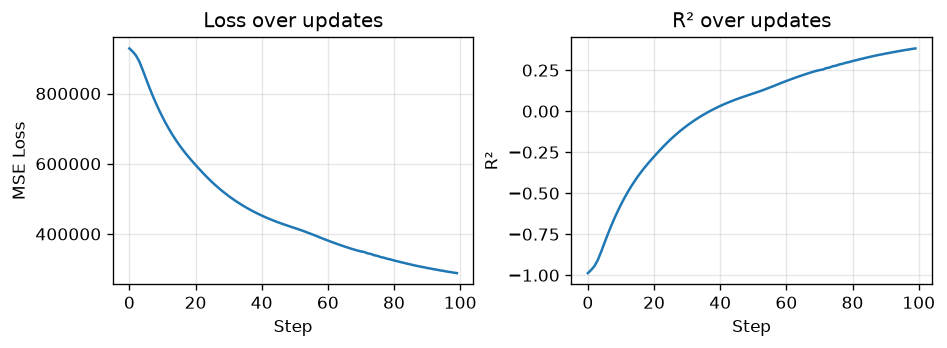

In [18]:
plt.figure(figsize=(8, 3))

# Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Loss over updates')
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)

# R²
plt.subplot(1, 2, 2)
plt.plot(r2_history)
plt.title('R² over updates')
plt.xlabel('Step')
plt.ylabel('R²')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. 핵심 정리

- Neural Network는 **Linear + Activation**을 연결하여 만든다.
- `nn.Linear`는 입력을 다른 차원의 벡터로 바꾸는 층이다.
- 범주형 자료는 neural network에 넣기 위해 **one-hot encoding**이 필요하다.
- `loss.backward()`는 loss를 기준으로 각 parameter의 gradient를 계산한다.
- 계산된 gradient는 각 parameter의 `.grad`에 저장된다.
- gradient를 이용해 parameter를 직접 업데이트할 수 있다.
- update를 반복하면 같은 batch에서 loss와 RMSE가 감소하며 R2가 증가하는 모습을 확인할 수 있다.

## 15. 연습 문제

### 📝 Exercise 1

`w`, `b`, `x`의 gradient 중 각각이 무엇을 의미하는지 설명해보세요.

---

### 📝 Exercise 2

모델에서 hidden layer를 하나 더 추가한 `DeeperDNN`을 만들어보세요.

힌트:

```python
deeper_model = nn.Sequential(
    nn.Linear(11, 16),
    nn.Sigmoid(),
    nn.Linear(16, 8),
    nn.Sigmoid(),
    nn.Linear(8, 1)
)
```

- gradient shape는 어떻게 달라지는가?
- loss 감소 속도는 어떻게 달라지는가?

---

### 📝 Exercise 3

모델의 hidden dimension을 `16` 대신 `8`, `32`로 바꿔보세요.

- gradient shape는 어떻게 달라지는가?
- loss 감소 속도는 어떻게 달라지는가?

---

### 📝 Exercise 4

반복 횟수를 `100`에서 `500`으로 늘려서 같은 배치에서 loss와 R²가 어떻게 변하는지 확인해보세요.

---

### 📝 Exercise 5

learning rate를 `0.01`, `0.1`로 바꿔서 loss 변화를 비교해보세요.

- 어느 경우가 더 천천히 줄어드는가?
- 어느 경우가 너무 크게 움직일 수 있는가?

---

### 📝 Challenge

Exercise를 통해 여러 번 학습해도 R²가 어느 수준에서 더 이상 크게 증가하지 않는 모습을 확인할 수 있습니다.

왜 R²가 계속 증가하여 1에 가까워지지 않을까요?

힌트: 다음 관점에서 생각해보세요.
- neural network의 구조
- 입력변수의 정보량
- 같은 batch에 대한 반복 학습의 한계